#Predictive Analytics for Urban Water Demand

This project predicts daily water usage based on:
- Household Size
- Seasonal Index
- Garden Area

In [30]:
#Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso ,Ridge
from sklearn.metrics import r2_score , mean_squared_error
import matplotlib.pyplot as plt

## Data Loading

Dataset is loaded using pandas to begin analysis.

In [31]:
df = pd.read_csv("Dataset.csv")

In [32]:
# Display first 5 rows
df.head()

,Household_Size,Seasonal_Index,Garden_Area,Daily_Liters_Used
0,4.0,1.361538,45.438517,743.564596
1,5.0,0.852185,17.747277,604.828887
2,3.0,1.490821,122.269659,678.494106
3,5.0,1.340571,138.737229,-965.195702
4,5.0,0.939101,13.151687,645.035740


In [33]:
# Check the number of rows and columns in the dataset
df.shape

(100, 4)

In [34]:
# Display all column names in the dataset
df.columns

Index(['Household_Size', 'Seasonal_Index', 'Garden_Area', 'Daily_Liters_Used'], dtype='str')

## Exploratory Data Analysis (EDA)

EDA helps in understanding structure, missing values, and statistical properties of data.

In [35]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Household_Size     100 non-null    float64
 1   Seasonal_Index     100 non-null    float64
 2   Garden_Area        90 non-null     float64
 3   Daily_Liters_Used  100 non-null    float64
dtypes: float64(4)
memory usage: 3.3 KB


In [36]:
# Statistical summary
df.describe()

,Household_Size,Seasonal_Index,Garden_Area,Daily_Liters_Used
count,100.000000,100.000000,90.000000,100.000000
mean,3.690000,1.142287,107.875130,791.228181
std,1.624901,0.205220,56.481770,1862.371420
min,1.000000,0.803865,10.961701,-965.195702
25%,2.000000,0.969002,56.053460,358.012592
50%,4.000000,1.146865,116.885437,596.918845
75%,5.000000,1.332696,151.561535,785.923298
max,6.000000,1.490821,198.110232,16938.727309


In [37]:
# Check missing values
df.isnull().sum()

Household_Size        0
Seasonal_Index        0
Garden_Area          10
Daily_Liters_Used     0
dtype: int64

## Data Cleaning

Missing values are handled and duplicate rows are removed.

In [38]:
# Fill missing values with mean
df.fillna(df.mean(), inplace=True)

,Household_Size,Seasonal_Index,Garden_Area,Daily_Liters_Used
0,4.0,1.361538,45.438517,743.564596
1,5.0,0.852185,17.747277,604.828887
2,3.0,1.490821,122.269659,678.494106
3,5.0,1.340571,138.737229,-965.195702
4,5.0,0.939101,13.151687,645.035740
...,...,...,...,...
95,4.0,1.243471,36.615963,679.130293
96,4.0,1.175042,108.482634,661.949073
97,5.0,0.863203,107.875130,652.703807
98,1.0,1.384712,150.746037,252.271064


In [39]:
# Remove rows with missing (null) values from the dataset
df.dropna(inplace=True)

In [40]:
# Remove duplicates
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [41]:
# Display the data type of each column in the dataset
df.dtypes

Household_Size       float64
Seasonal_Index       float64
Garden_Area          float64
Daily_Liters_Used    float64
dtype: object

## Feature Selection

Selecting input features and target variable for the model.

In [42]:
# Input features(Independent variable)
X = df[['Household_Size', 'Seasonal_Index', 'Garden_Area']]
## Target variable(Dependent variable)
y = df['Daily_Liters_Used']

In [43]:
# Display first 5 rows of input features (X) and target variable (y)
print(X.head())
print(y.head())

   Household_Size  Seasonal_Index  Garden_Area
0             4.0        1.361538    45.438517
1             5.0        0.852185    17.747277
2             3.0        1.490821   122.269659
3             5.0        1.340571   138.737229
4             5.0        0.939101    13.151687
0    743.564596
1    604.828887
2    678.494106
3   -965.195702
4    645.035740
Name: Daily_Liters_Used, dtype: float64


In [44]:
# Compute correlation matrix to understand relationships between numerical features
df.corr()

,Household_Size,Seasonal_Index,Garden_Area,Daily_Liters_Used
Household_Size,1.000000,-0.226225,-0.016063,0.204632
Seasonal_Index,-0.226225,1.000000,-0.046972,0.160251
Garden_Area,-0.016063,-0.046972,1.000000,0.064314
Daily_Liters_Used,0.204632,0.160251,0.064314,1.000000


In [45]:
# Display correlation of all features with the target variable (Daily_Liters_Used)
df.corr()['Daily_Liters_Used']

Household_Size       0.204632
Seasonal_Index       0.160251
Garden_Area          0.064314
Daily_Liters_Used    1.000000
Name: Daily_Liters_Used, dtype: float64

## Train-Test Split

Splitting dataset into training and testing sets.

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [47]:
# Check the shape of the training feature set (rows, columns)
X_train.shape

(80, 3)

In [48]:
# Check the shape of the test feature set (rows, columns)
X_test.shape

(20, 3)

## Feature Scaling

StandardScaler is used to standardize features.

In [49]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Training

Linear Regression ,Lasso,Ridge model is used for prediction.

In [50]:
lr = LinearRegression()
lasso = Lasso()
ridge = Ridge()

In [51]:
lr.fit(X_train, y_train) 
lasso.fit(X_train, y_train) 
ridge.fit(X_train, y_train) 





,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


## Prediction

Model is used to predict values on test data.

In [52]:
lr_predict = lr.predict(X_test) 
las_predict = lasso.predict(X_test) 
rid_predict = ridge.predict(X_test) 

## Model Evaluation

Evaluating model performance using MSE and R² score.

In [53]:
lr_msc = mean_squared_error(y_test , lr_predict)
las_msc = mean_squared_error(y_test , las_predict)
rid_msc = mean_squared_error(y_test , rid_predict)

In [54]:
lr_rsccore = r2_score(y_test , lr_predict)
las_rscore = r2_score(y_test , las_predict)
rid_rsccore = r2_score(y_test , rid_predict)

In [55]:
print("\nPerformance of liner regretion model")
print("R2score", lr_rsccore)
print("MSE:",lr_msc)

print("\nPerformance of Lasso  regretion model")
print("R2score",las_rscore )
print("MSE:",las_msc)

print("\nPerformance of Ridge regretion model")
print("R2score", rid_rsccore)
print("MSE:",rid_msc)


Performance of liner regretion model
R2score -0.7094919427001773
MSE: 205007.36301378976

Performance of Lasso  regretion model
R2score -0.6900857519718195
MSE: 202680.11484842002

Performance of Ridge regretion model
R2score -0.395900807868776
MSE: 167400.58054791723


## Visualization

Comparing actual and predicted values.

In [56]:
# Display all column names in the dataset
df.columns

Index(['Household_Size', 'Seasonal_Index', 'Garden_Area', 'Daily_Liters_Used'], dtype='str')

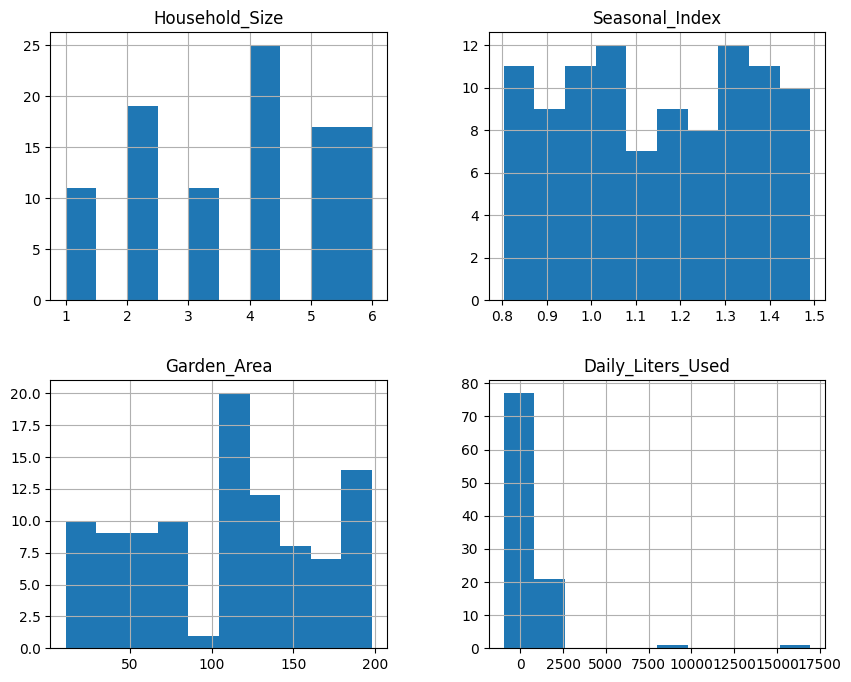

In [57]:
df.hist(figsize=(10,8))
plt.show()

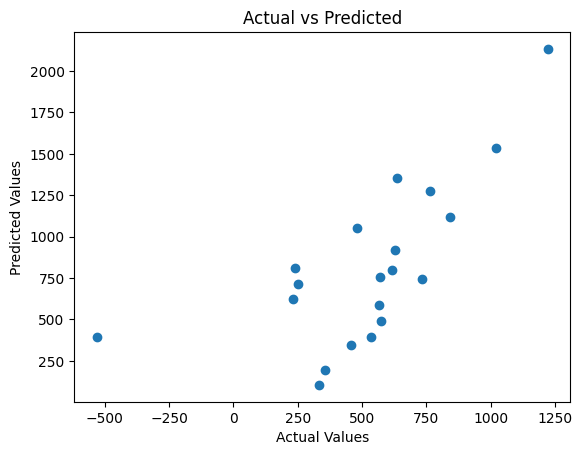

In [58]:
plt.scatter(y_test, lr_predict)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

## Conclusion

- Household size significantly affects water consumption
- Seasonal index influences usage patterns
- Linear Regression, Lasso, Ridge model performs well
- R² score indicates good prediction accuracy
- This model can help in efficient urban water management